<a href="https://colab.research.google.com/github/kayurh/data_analytics/blob/main/3_1_lecture_Kayur_Amour_Harry.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lesson 3 – DataFrame operations and relationships between variables (Part 1)

In real-world data analysis, data rarely arrives in a “clean, ready-to-use” format.
Very often, we first need to **reshape** our tables and then **connect** them with other tables.

In this notebook, we organize four fundamental operations that appear in almost every data project:

- **pivot**: when we create a *summary table* (wide / matrix-like view)
- **melt**: when we transform a wide table back into a *tidy/long* format  
  (ideal for visualization and for libraries like seaborn)
- **merge**: when we combine tables **based on a key**  
  (SQL-like joins: `on="id"`, `how="left"/"inner"`)
- **concat**: when we append **rows** (`axis=0`) or **columns** (`axis=1`)

The goal is not only to make the code run,
but to understand *which operation to use and when*,
and how to verify that the result really means what we think it means.

## Pivot – reshaping the data

Many datasets arrive in a *long* format: one row represents one observation.
For analysis and visualization, however, we often prefer a *wide* format:
categories organized into columns, with aggregated values.

`pivot_table` provides a controlled way to:
- choose what defines the row (`index`) and column dimensions,
- specify which values (`values`) we want to aggregate,
- decide which aggregation function (`aggfunc`) to apply.

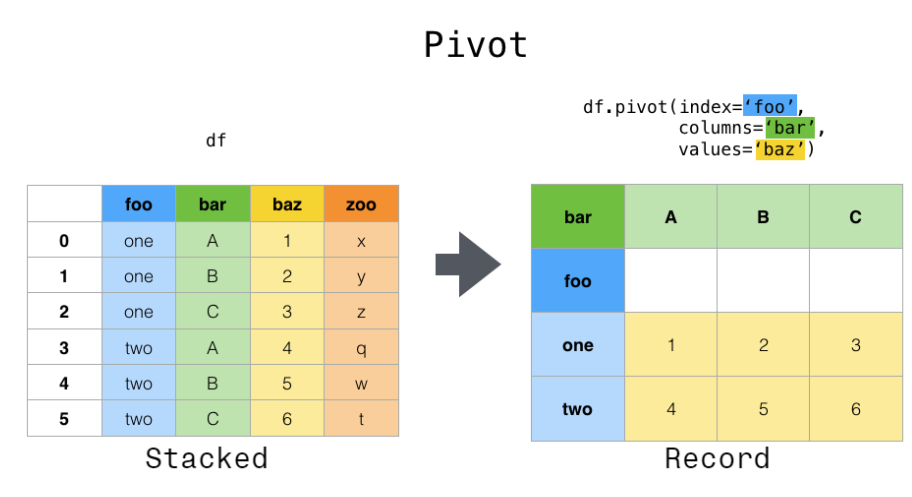

### The Titanic dataset

The Titanic dataset is one of the most well-known open-source datasets and is frequently used for practicing data processing, statistical analysis, and machine learning.  
It contains information about the passengers of the RMS Titanic, which sank on April 15, 1912, and focuses on identifying who survived the disaster.

#### Dataset characteristics

- **Source**: OpenML, originally based on Kaggle and various statistical publications  
- **Number of rows**: 1,309 passengers  
- **Number of columns**: 14 features  

#### Dataset columns

- **pclass** – Passenger class (1 = first, 2 = second, 3 = third class)  
- **sex** – Passenger gender (`male`, `female`)  
- **age** – Passenger age (some values are missing)  
- **sibsp** – Number of siblings and spouses aboard  
- **parch** – Number of parents and children aboard  
- **fare** – Ticket price (in pounds)  
- **embarked** – Port of embarkation (`C` = Cherbourg, `Q` = Queenstown, `S` = Southampton)  
- **home.dest** – Passenger’s home or destination  
- **survived** – Target variable (0 = did not survive, 1 = survived)  

#### Interesting facts about Titanic survival data

- First-class passengers had a much higher survival rate than third-class passengers.  
- Women had a significantly higher chance of survival than men.  
- Due to the “women and children first” rule, younger passengers were more likely to survive.

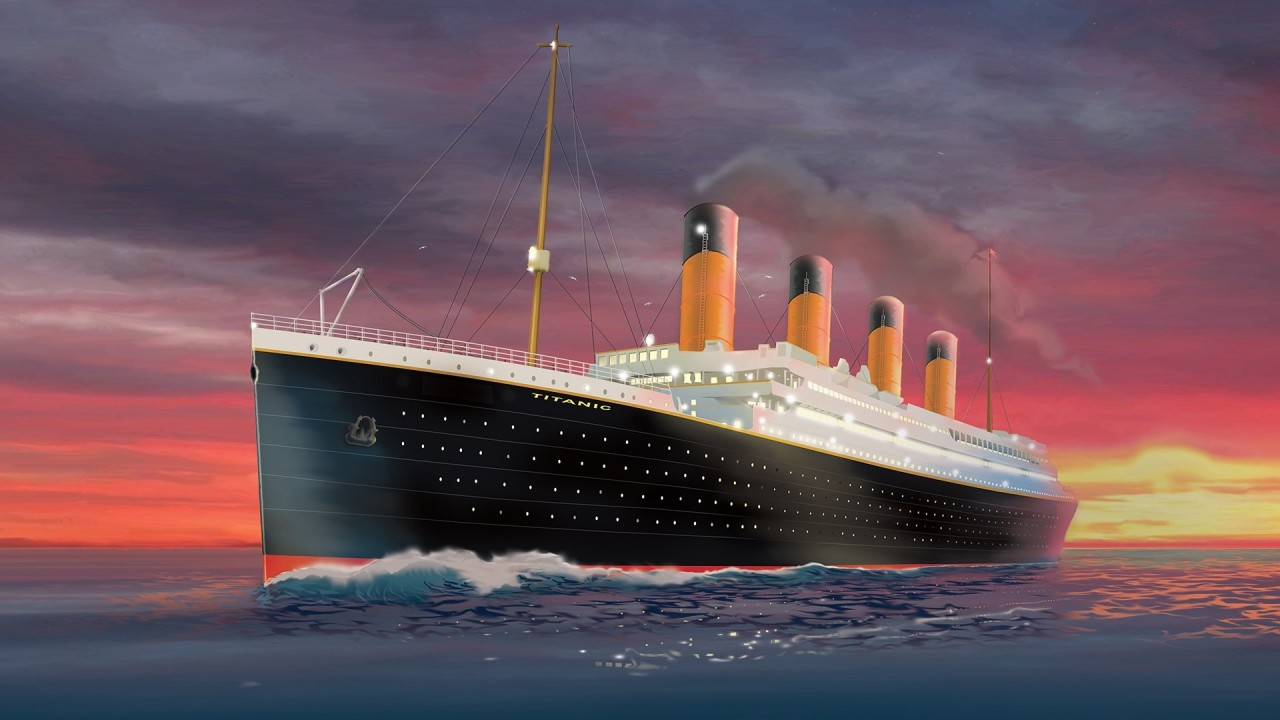

In [ ]:
# Loading the Titanic dataset using scikit-learn
from sklearn.datasets import fetch_openml
import pandas as pd

# Load data from the OpenML repository
titanic = fetch_openml(name="titanic", version=1, as_frame=True)

# Convert the data to a Pandas DataFrame
df = titanic.data

# Attach the target variable (y) and convert it to numeric format
df["survived"] = pd.to_numeric(titanic.target, errors="coerce")

# More details about the Titanic dataset:
# https://medium.com/data-science/machine-learning-with-the-titanic-dataset-7f6909e58280

# More details about sklearn.datasets:
# https://scikit-learn.org/stable/api/sklearn.datasets.html

In [ ]:
df.head()

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,survived
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO",1
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON",1
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON",0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",0


In [ ]:
# Average survival rate by gender and passenger class.
# The pivot table shows, for each gender (rows),
# how survival probability changes across passenger classes (columns).
# This helps reveal whether the effect of passenger class differs
# between men and women.
pt = pd.pivot_table(
    df,
    index="sex",
    columns="pclass",
    values="survived",
    aggfunc="mean"
)

pt

/tmp/ipython-input-1060/3862538303.py:6: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pt = pd.pivot_table(


pclass,1,2,3
sex,,,
female,0.965278,0.886792,0.490741
male,0.340782,0.146199,0.152130


The values in the table represent the survival rate for each group (`sex × pclass`).
Since the `survived` variable is binary (0/1), its mean can be interpreted directly as a proportion.

Another example, with median ticket prices.


In [ ]:
# Typical ticket price (median) by gender and passenger class.
# The median is useful because it is less sensitive to extreme values
# (very expensive tickets).
# This helps us understand how ticket prices differ by gender and class,
# and also provides context for interpreting survival rates.
pd.pivot_table(
    df,
    index="sex",
    columns="pclass",
    values="fare",
    aggfunc="median"
)

/tmp/ipython-input-1060/2838743376.py:6: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pd.pivot_table(


pclass,1,2,3
sex,,,
female,80.92915,23.0,10.4896
male,49.50420,13.0,7.8958


### Why do you think the median ticket price is higher for women?

- Did women actually pay more than men?

### Median vs. Mean

**Note:** for symmetric distributions, the mean ≈ median for skewed distributions, they can differ substantially.

**Mean:** the sum of values divided by the number of observations → sensitive to outliers.  
**Median:** the middle value of the sorted data → a good representation of the “typical” value.

We will discuss how to handle **skewed data** in more detail in a later chapter.




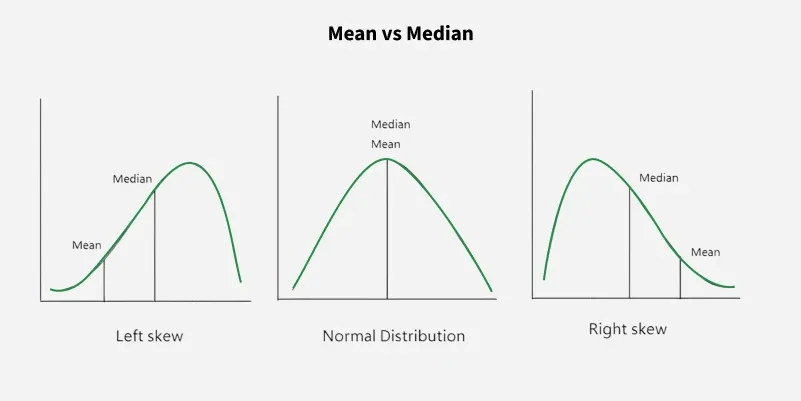

## Melt – converting data back to long format

During pivoting, data is often transformed into a *wide* format,
where the values of a variable are spread across multiple columns.

For visualization and further analysis, however,
the *long (tidy)* format is often ideal:
- one row = one observation  
- one column = one variable  

Using `melt`, we can transform a wide table back
into a structured, long format.
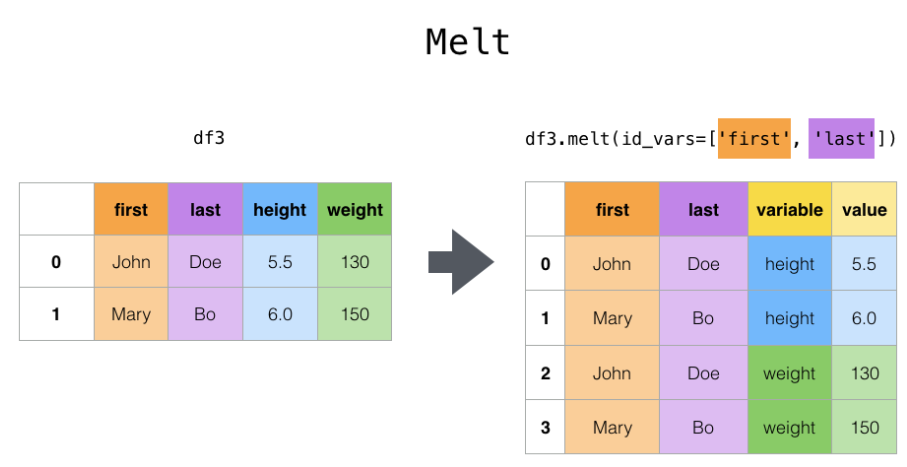

In [ ]:
# Pivot table with the index reset
pt_reset = pt.reset_index()
pt_reset


pclass,sex,1,2,3
0,female,0.965278,0.886792,0.490741
1,male,0.340782,0.146199,0.152130


In [ ]:
# melt table
df_long = pd.melt(
                pt_reset,
                id_vars="sex",
                var_name="pclass",
                value_name="survival_rate"
            )
df_long

,sex,pclass,survival_rate
0,female,1,0.965278
1,male,1,0.340782
2,female,2,0.886792
3,male,2,0.146199
4,female,3,0.490741
5,male,3,0.152130


The result is a *long-format* table:
- each row describes a specific (`sex × pclass`) combination,
- the survival rate appears in a single column.

This format is ideal for:
- creating plots,
- applying further filters,
- or performing additional grouping operations.


### Pivot vs. Melt – a conceptual summary

- `pivot_table`: summarize + reshape  
- `melt`: reshape + structure  

The two operations can be seen as inverses of each other,
and together they form a bridge between different data formats.

### Why does this matter?

Most visualization libraries (e.g. seaborn, plotly)
prefer data in a *long (tidy)* format.

In the next step, we will use this table
to create different types of plots.

## Merge – combining two tables into one

In practice, data rarely lives in a single table.
It often comes from multiple sources, or we create several derived tables
that need to be connected using one or more shared keys.

The core idea of `merge`:
- specify the common key (`on=...` or `left_on` / `right_on`),
- choose the type of relationship (`how=`: inner, left, right, outer),
- and make sure the keys are unique (otherwise rows may be duplicated).

In [ ]:
# Average ticket price by passenger class.
# Using groupby + mean shows how much passengers paid on average
# in each class.
# This helps quantify the economic differences between classes.
fare_by_class = df.groupby("pclass")["fare"].mean()
fare_by_class

,fare
pclass,
1,87.508992
2,21.179196
3,13.302889


In [ ]:
fare_by_class = fare_by_class.reset_index()
fare_by_class

,pclass,fare
0,1,87.508992
1,2,21.179196
2,3,13.302889


In [ ]:
# Rename the column to a more descriptive name
fare_by_class = fare_by_class.rename(columns={"fare": "avg_fare_in_class"})
fare_by_class

,pclass,avg_fare_in_class
0,1,87.508992
1,2,21.179196
2,3,13.302889


In [ ]:
# Merge it back into the original DataFrame
df2 = pd.merge(df,fare_by_class, on="pclass", how="left")
df2.head()

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,survived,avg_fare_in_class
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO",1,87.508992
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON",1,87.508992
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",0,87.508992
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON",0,87.508992
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",0,87.508992


### Important: a merge can multiply rows!

If the key is not unique on one or both sides,
a merge may create a 1:N or N:N relationship,
leading to duplicated rows.

For this reason, it is always worth checking before a merge:
- whether the key is unique (`is_unique`),
- and how the table size changes before and after the operation (`shape`).


In [ ]:
print(fare_by_class["pclass"].is_unique)
print(df["pclass"].is_unique)
df.shape, df2.shape


True
False


((1309, 14), (1309, 15))

## Concat – combining tables

Not every data combination involves key-based joins (`merge`).
Very often, we want to:
- stack multiple tables with the same structure vertically or horizontally,
- or combine results from different measurements or subsets.

This is what `concat` is used for.

In [ ]:
# Stack tables vertically (axis=0)
# Example: women and men from separate tables
df_female = df[df["sex"] == "female"]
df_male = df[df["sex"] == "male"]

df_concat = pd.concat([df_female, df_male])
df_concat


,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,survived
0,1,"Allen, Miss. Elisabeth Walton",female,29.0,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO",1
2,1,"Allison, Miss. Helen Loraine",female,2.0,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",0
6,1,"Andrews, Miss. Kornelia Theodosia",female,63.0,1,0,13502,77.9583,D7,S,10,NaN,"Hudson, NY",1
8,1,"Appleton, Mrs. Edward Dale (Charlotte Lamson)",female,53.0,2,0,11769,51.4792,C101,S,D,NaN,"Bayside, Queens, NY",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1302,3,"Yousif, Mr. Wazli",male,NaN,0,0,2647,7.2250,NaN,C,NaN,NaN,NaN,0
1303,3,"Yousseff, Mr. Gerious",male,NaN,0,0,2627,14.4583,NaN,C,NaN,NaN,NaN,0
1306,3,"Zakarian, Mr. Mapriededer",male,26.5,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN,0
1307,3,"Zakarian, Mr. Ortin",male,27.0,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN,0


By default, `concat` combines tables along rows (`axis=0`).
It is important that the column structure matches.


### Index issues (very important!)

In [ ]:
# Bad example – concatenating columns with mismatched indexes (axis=1)
# Two separate tables (5 rows each, 1 column each)

df_a = pd.DataFrame(
    {"A": [10, 20, 30, 40, 50]},
    index=[0, 1, 2, 3, 4]
)

df_b = pd.DataFrame(
    {"B": [100, 200, 300, 400, 500]},
    index=[2, 3, 4, 5, 6]
)

print(df_a)
print(df_b)


    A
0  10
1  20
2  30
3  40
4  50
     B
2  100
3  200
4  300
5  400
6  500


We can observe that the index is not unique.
This is not an error, but in many cases it can be confusing.

In [ ]:
# Concatenation along columns (incorrect approach)
df_bad = pd.concat([df_a, df_b], axis=1)
df_bad


,A,B
0,10.0,NaN
1,20.0,NaN
2,30.0,100.0
3,40.0,200.0
4,50.0,300.0
5,NaN,400.0
6,NaN,500.0


Why is this dangerous?

In [ ]:
# dropna() removes rows that contain at least one missing value (NaN).
# This is a quick solution, but it may lead to data loss,
# so always check how many rows you are dropping.
df_bad.dropna()

# We will discuss dropna() in more detail later.

,A,B
2,30.0,100.0
3,40.0,200.0
4,50.0,300.0


Only 3 rows remain, and data loss occurs silently.

Students often assume that:
- “row 1 of one table is placed next to row 1 of the other table”  
- This is **NOT** how pandas works.  
- Here, `concat` aligns data **based on the index**.

Correct solution – aligning the indexes





In [ ]:
# Concatenate the two tables column-wise (axis=1) without aligning by index.
# Therefore, we reset the index of both DataFrames to a clean 0..N-1 range
# using reset_index(drop=True).
# This ensures that rows are placed next to each other by position,
# not by index values.
df_good = pd.concat(
    [
        df_a.reset_index(drop=True),
        df_b.reset_index(drop=True)
    ],
    axis=1
)

# Result: columns of df_a and columns of df_b placed side by side,
# with rows correctly aligned by position
df_good

,A,B
0,10,100
1,20,200
2,30,300
3,40,400
4,50,500


Important: when using `concat(axis=1)`, pandas aligns data by **index**,
not by row position.

If the indexes do not match:
- `NaN` values may appear,
- or data loss can occur.

Therefore, before concatenating columns, always check the indexes
or standardize them.


### Exercises

In the following, we will create a small dataset
and solve three simple tasks on it.

In [1]:
import pandas as pd

# Small dataset for practicing concat + index alignment
df_left = pd.DataFrame({
    "id": [101, 102, 103, 104],
    "name": ["Anna", "Bela", "Csaba", "Dora"],
    "age": [23, 45, 32, 29]
})

df_right = pd.DataFrame({
    "id": [101, 103, 104, 105],      # note: intentional mismatch – 102 is missing, 105 is extra
    "city": ["Szeged", "Budapest", "Zenta", "Subotica"],
    "score": [88, 91, 77, 85]
})

display(df_left)
display(df_right)

,id,name,age
0,101,Anna,23
1,102,Bela,45
2,103,Csaba,32
3,104,Dora,29


,id,city,score
0,101,Szeged,88
1,103,Budapest,91
2,104,Zenta,77
3,105,Subotica,85


In [2]:
df_left.set_index('id',inplace=True)
df_right.set_index('id',inplace=True)
display(df_right)
display(df_left)

,city,score
id,,
101,Szeged,88
103,Budapest,91
104,Zenta,77
105,Subotica,85


,name,age
id,,
101,Anna,23
102,Bela,45
103,Csaba,32
104,Dora,29


## Task 1 – `concat` row-wise (axis=0)

Create a new table such that:

1. `df_left` and `df_right` are stacked *vertically* (`axis=0`).
2. Observe what happens to the columns (which ones become `NaN`?).
3. Repeat the operation with the index reset (`ignore_index=True`).

**Question:**  
Why do missing values appear when the column sets differ?

In [3]:
t1 = pd.concat([df_left, df_right], axis=0)
print(t1)

t2 = pd.concat([df_left, df_right], axis=0, ignore_index=True)
print(t2)

      name   age      city  score
id                               
101   Anna  23.0       NaN    NaN
102   Bela  45.0       NaN    NaN
103  Csaba  32.0       NaN    NaN
104   Dora  29.0       NaN    NaN
101    NaN   NaN    Szeged   88.0
103    NaN   NaN  Budapest   91.0
104    NaN   NaN     Zenta   77.0
105    NaN   NaN  Subotica   85.0
    name   age      city  score
0   Anna  23.0       NaN    NaN
1   Bela  45.0       NaN    NaN
2  Csaba  32.0       NaN    NaN
3   Dora  29.0       NaN    NaN
4    NaN   NaN    Szeged   88.0
5    NaN   NaN  Budapest   91.0
6    NaN   NaN     Zenta   77.0
7    NaN   NaN  Subotica   85.0


## Task 2 – `concat` column-wise (axis=1) and index alignment

Now let’s create two tables with the same number of rows,
but with *misaligned indexes*.

1. Create:
   - `A = df_left[["name", "age"]].copy()`
   - `B = df_right[["city", "score"]].copy()`
2. Set the indexes as follows:
   - `A.index = [0, 1, 2, 3]`
   - `B.index = [1, 2, 3, 4]`  (intentionally shifted)
3. Concatenate them using `pd.concat([A, B], axis=1)`.
4. Observe: where do `NaN` values appear, and why?

**Fix (required):**
- Correct the result so that the two tables are placed *side by side row by row*
  without index-alignment issues.

**Hint:** use `reset_index(drop=True)` on both tables before concatenation.

In [4]:
A = df_left[["name", "age"]].copy()
B = df_right[["city", "score"]].copy()

A.index = [0, 1, 2, 3]
B.index = [1, 2, 3, 4]

t3 = pd.concat([A, B], axis=1)
print(t3)

t4 = pd.concat([A.reset_index(drop=True), B.reset_index(drop=True)], axis=1)
print(t4)

    name   age      city  score
0   Anna  23.0       NaN    NaN
1   Bela  45.0    Szeged   88.0
2  Csaba  32.0  Budapest   91.0
3   Dora  29.0     Zenta   77.0
4    NaN   NaN  Subotica   85.0
    name  age      city  score
0   Anna   23    Szeged     88
1   Bela   45  Budapest     91
2  Csaba   32     Zenta     77
3   Dora   29  Subotica     85


## Task 3 – `concat` or `merge`?

In `df_left` and `df_right`, the common key is `id`.

1. Try to “combine” the two tables using `concat` so that they align by `id`.
   - What do you observe? Does this produce a meaningful result?

2. Then create a correct join using `merge`:
   - `how="left"` (keep all rows from `df_left`)

**Question:**  
What is the difference between `concat(axis=1)` and `merge(on="id")`?  
When would you use one versus the other?

In [5]:
t5 = pd.concat([df_left, df_right], axis=1)
print(t5)

df_left_reset = df_left.reset_index()
df_right_reset = df_right.reset_index()

t6 = pd.merge(df_left_reset, df_right_reset, on="id", how="left")
print(t6)

      name   age      city  score
id                               
101   Anna  23.0    Szeged   88.0
102   Bela  45.0       NaN    NaN
103  Csaba  32.0  Budapest   91.0
104   Dora  29.0     Zenta   77.0
105    NaN   NaN  Subotica   85.0
    id   name  age      city  score
0  101   Anna   23    Szeged   88.0
1  102   Bela   45       NaN    NaN
2  103  Csaba   32  Budapest   91.0
3  104   Dora   29     Zenta   77.0
